# Human Activity Recognition Using Hidden Markov Models

This notebook implements a complete Hidden Markov Model pipeline for classifying human physical activities from accelerometer and gyroscope sensor data.

## Problem Overview

We aim to recognize four distinct human activities:
- **Standing**: Stationary position at waist level
- **Walking**: Continuous walking motion with consistent pace
- **Jumping**: Repeated jumping motion
- **Still**: Stationary position on flat surface

## Methodology

1. **Feature Extraction**: Extract time-domain and frequency-domain features from sensor windows
2. **Model Architecture**: Implement Gaussian Hidden Markov Model with four states
3. **Training**: Fit HMM parameters using Baum-Welch (EM) algorithm on labeled data
4. **Inference**: Use Viterbi algorithm to decode most likely activity sequences
5. **Evaluation**: Assess model performance on held-out test sequences

## 1. Environment Setup

Import the necessary libraries for data processing, visualization, and machine learning.

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import os
import warnings
import requests
from io import StringIO

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

np.random.seed(42)

print("Environment setup complete.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Environment setup complete.
NumPy version: 2.4.2
Pandas version: 3.0.1


## 2. Data Loading and Exploration

Load accelerometer and gyroscope sensor data from CSV files. Each activity has multiple recording sessions stored as separate files, which preserves temporal boundaries needed for sequence-based HMM training.

In [101]:
GITHUB_DATA_URL = 'https://raw.githubusercontent.com/Mugisha-isaac/Human-Activities-State/master/data'

ACTIVITIES = {
    'standing_waist': (0, 'Standing'),
    'walking':        (1, 'Walking'),
    'jumping':        (2, 'Jumping'),
    'still':          (3, 'Still')
}


def standardize_column_names(df):
    """Standardize column names to snake_case format for consistency.
    
    Handles various naming conventions for accelerometer and gyroscope axes
    across different sensor formats.
    """
    df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')
    column_mapping = {
        # Accelerometer variants
        'accelx': 'accel_x', 'accely': 'accel_y', 'accelz': 'accel_z',
        'acc_x': 'accel_x', 'acc_y': 'accel_y', 'acc_z': 'accel_z',
        'ax': 'accel_x', 'ay': 'accel_y', 'az': 'accel_z',
        'accelerometer_x': 'accel_x', 'accelerometer_y': 'accel_y', 'accelerometer_z': 'accel_z',
        # Gyroscope variants
        'gyrox': 'gyro_x', 'gyroy': 'gyro_y', 'gyroz': 'gyro_z',
        'gx': 'gyro_x', 'gy': 'gyro_y', 'gz': 'gyro_z',
        'roll': 'gyro_x', 'pitch': 'gyro_y', 'yaw': 'gyro_z',
        'gyroscope_x': 'gyro_x', 'gyroscope_y': 'gyro_y', 'gyroscope_z': 'gyro_z',
        # Timestamp variants
        'time': 'timestamp', 'timestamp_ms': 'timestamp', 'time_ms': 'timestamp'
    }
    df.rename(columns=column_mapping, inplace=True)
    return df


# Configuration
USE_GITHUB   = False
LOCAL_DATA_DIR = '../data'

print("Loading training data from activity subfolders...\n")

# Load TRAINING data while preserving file-level sequences
train_per_file_data = []
activity_names = {}
failed_activities = []

for subfolder, (label, name) in sorted(ACTIVITIES.items()):
    try:
        # Load each CSV file individually to preserve sequence boundaries
        subfolder_path = os.path.join(LOCAL_DATA_DIR, 'train', subfolder)
        csv_files = sorted([f for f in os.listdir(subfolder_path) if f.endswith('.csv')])
        
        for filename in csv_files:
            filepath = os.path.join(subfolder_path, filename)
            df = pd.read_csv(filepath)
            if df.shape[0] > 0:
                df = standardize_column_names(df)
                train_per_file_data.append((df, label))
        
        activity_names[label] = name
        total = sum(d.shape[0] for d, l in train_per_file_data if l == label)
        print(f"{name:<15} | Files: {len(csv_files):<2} | Samples: {total}")
    
    except Exception as e:
        print(f"{name:<15} | Error: {str(e)}")
        failed_activities.append(name)

print(f"\nLoaded {len(activity_names)}/{len(ACTIVITIES)} activities for training | Total files: {len(train_per_file_data)}")

# Load TEST data from the test folder (flat structure)
print("\nLoading test data from test folder...\n")

test_per_file_data = []

# Map activity names (case-insensitive) to labels
activity_name_to_label = {}
for subfolder, (label, name) in ACTIVITIES.items():
    activity_name_to_label[name.lower()] = label
    activity_name_to_label[subfolder.lower()] = label

test_folder_path = os.path.join(LOCAL_DATA_DIR, 'test')
test_files = sorted([f for f in os.listdir(test_folder_path) if f.endswith('.csv')])

test_count_by_activity = {label: 0 for label in activity_names}

for filename in test_files:
    try:
        filepath = os.path.join(test_folder_path, filename)
        df = pd.read_csv(filepath)
        
        if df.shape[0] == 0:
            continue
        
        df = standardize_column_names(df)
        
        # Infer activity label from filename
        filename_lower = filename.lower()
        activity_label = None
        
        for activity_name, label in activity_name_to_label.items():
            if activity_name.replace('_', '') in filename_lower:
                activity_label = label
                break
        
        if activity_label is not None:
            test_per_file_data.append((df, activity_label))
            test_count_by_activity[activity_label] += 1
            print(f"    Loaded: {filename} ({df.shape[0]} rows) → {activity_names[activity_label]}")
        else:
            print(f"    Warning: Could not determine activity for {filename}")
    
    except Exception as e:
        print(f"    Error loading {filename}: {str(e)}")

print(f"\nTest data summary:")
for label, count in test_count_by_activity.items():
    if count > 0:
        total = sum(d.shape[0] for d, l in test_per_file_data if l == label)
        print(f"  {activity_names[label]}: {count} files, {total} total samples")

print(f"\nTotal test files loaded: {len(test_per_file_data)}")

Loading training data from activity subfolders...

Jumping         | Files: 5  | Samples: 5682
Standing        | Files: 7  | Samples: 7665
Still           | Files: 5  | Samples: 5371
Walking         | Files: 5  | Samples: 5420

Loaded 4/4 activities for training | Total files: 22

Loading test data from test folder...

    Loaded: setB_Jumping_1-2025-10-24_15-15-26_cleaned.csv (1056 rows) → Jumping
    Loaded: setB_Jumping_2-2025-10-24_15-16-46_cleaned.csv (1230 rows) → Jumping
    Loaded: setB_Jumping_3-2025-10-24_15-18-46_cleaned.csv (1134 rows) → Jumping
    Loaded: setB_Standing_1-2025-10-26_13-29-15_cleaned.csv (1577 rows) → Standing
    Loaded: setB_Standing_2-2025-10-26_13-28-55_cleaned.csv (1364 rows) → Standing

Test data summary:
  Jumping: 3 files, 3420 total samples
  Standing: 2 files, 2941 total samples

Total test files loaded: 5


## 3. Feature Extraction

We extract both **time-domain** and **frequency-domain** features from sliding windows over each recording.
Crucially, we **preserve which file each window came from** so we can build proper per-sequence training and test sets — a requirement for the HMM to learn meaningful temporal structure.

In [102]:
class FeatureExtractor:
    """
    Extract time-domain and frequency-domain features from sensor signals.

    Window size and overlap are tuned to the sampling rate so that each
    window represents roughly 0.5 s of data and adjacent windows share 50%
    of their samples.
    """

    WINDOW_SIZE = 50
    OVERLAP     = 25

    @staticmethod
    def extract_time_domain_features(sig):
        sig = np.asarray(sig, dtype=np.float64)
        return {
            'mean':     np.mean(sig),
            'std':      np.std(sig),
            'variance': np.var(sig),
            'min':      np.min(sig),
            'max':      np.max(sig),
            'range':    np.max(sig) - np.min(sig),
            'rms':      np.sqrt(np.mean(sig ** 2)),
            'mad':      np.mean(np.abs(sig - np.mean(sig))),
            # Additional discriminative features
            'skewness': float(stats.skew(sig)),
            'kurtosis': float(stats.kurtosis(sig)),
            'iqr':      float(np.percentile(sig, 75) - np.percentile(sig, 25)),
            'energy':   float(np.sum(sig ** 2)),
        }

    @staticmethod
    def extract_frequency_domain_features(sig, sampling_rate=50):
        sig = np.asarray(sig, dtype=np.float64)
        fft_vals = np.abs(np.fft.fft(sig))
        fft_freq = np.fft.fftfreq(len(sig), 1 / sampling_rate)

        pos_idx   = fft_freq > 0
        fft_vals  = fft_vals[pos_idx]
        fft_freq  = fft_freq[pos_idx]

        total_power = np.sum(fft_vals) + 1e-10
        norm_power  = fft_vals / total_power

        dom_idx = np.argmax(fft_vals) if len(fft_vals) > 0 else 0

        return {
            'spectral_energy':   np.sum(fft_vals ** 2),
            'spectral_entropy':  float(-np.sum(norm_power * np.log(norm_power + 1e-10))),
            'dominant_freq':     fft_freq[dom_idx] if len(fft_freq) > 0 else 0.0,
            'freq_centroid':     float(np.sum(fft_freq * fft_vals) / total_power),
            # Energy in activity-relevant bands
            'band_0_2hz':        float(np.sum(fft_vals[(fft_freq >= 0)   & (fft_freq < 2)]  ** 2)),
            'band_2_5hz':        float(np.sum(fft_vals[(fft_freq >= 2)   & (fft_freq < 5)]  ** 2)),
            'band_5_10hz':       float(np.sum(fft_vals[(fft_freq >= 5)   & (fft_freq < 10)] ** 2)),
        }

    @staticmethod
    def compute_sma(ax, ay, az):
        return float(np.mean(np.sqrt(
            np.asarray(ax) ** 2 +
            np.asarray(ay) ** 2 +
            np.asarray(az) ** 2
        )))

    @staticmethod
    def safe_corr(a, b):
        c = np.corrcoef(np.asarray(a), np.asarray(b))[0, 1]
        return float(c) if not np.isnan(c) else 0.0

    @classmethod
    def extract_window_features(cls, window, sampling_rate=50):
        features = {}

        for axis in ['x', 'y', 'z']:
            for sensor in ['accel', 'gyro']:
                col = f'{sensor}_{axis}'
                if col in window.columns:
                    sig = window[col].values
                    for k, v in cls.extract_time_domain_features(sig).items():
                        features[f'{col}_time_{k}'] = v
                    for k, v in cls.extract_frequency_domain_features(sig, sampling_rate).items():
                        features[f'{col}_freq_{k}'] = v

        if all(c in window.columns for c in ['accel_x', 'accel_y', 'accel_z']):
            features['accel_sma'] = cls.compute_sma(
                window['accel_x'].values,
                window['accel_y'].values,
                window['accel_z'].values
            )
            features['accel_xy_corr'] = cls.safe_corr(window['accel_x'].values, window['accel_y'].values)
            features['accel_xz_corr'] = cls.safe_corr(window['accel_x'].values, window['accel_z'].values)
            features['accel_yz_corr'] = cls.safe_corr(window['accel_y'].values, window['accel_z'].values)

        if all(c in window.columns for c in ['gyro_x', 'gyro_y', 'gyro_z']):
            features['gyro_sma'] = cls.compute_sma(
                window['gyro_x'].values,
                window['gyro_y'].values,
                window['gyro_z'].values
            )

        return features

    @classmethod
    def extract_from_dataframe(cls, df, sampling_rate=50, window_size=None, overlap=None):
        """Return a feature matrix (n_windows x n_features) for one recording."""
        window_size = window_size or cls.WINDOW_SIZE
        overlap     = overlap     or cls.OVERLAP
        stride      = window_size - overlap

        feature_list = []
        for start in range(0, len(df) - window_size + 1, stride):
            window = df.iloc[start: start + window_size]
            feature_list.append(cls.extract_window_features(window, sampling_rate))

        return pd.DataFrame(feature_list)


print("FeatureExtractor class defined.")

FeatureExtractor class defined.


In [103]:
# Extract features from TRAINING data while preserving per-file boundaries.
# train_sequences_by_label[label] = list of 2-D numpy arrays (n_windows, n_features)
print("Extracting features from training recordings...\n")

train_sequences_by_label = {label: [] for _, (label, _) in ACTIVITIES.items()}

for df, label in train_per_file_data:
    feat_df = FeatureExtractor.extract_from_dataframe(df)
    if len(feat_df) >= 3:          # skip recordings that are too short
        train_sequences_by_label[label].append(feat_df.values.astype(np.float64))

for label, seqs in train_sequences_by_label.items():
    total_windows = sum(s.shape[0] for s in seqs)
    print(f"  {activity_names[label]}: {len(seqs)} sequences, {total_windows} windows")

n_features = next(iter(train_sequences_by_label.values()))[0].shape[1]
print(f"\nFeature dimension: {n_features}")

# Extract features from TEST data
print("\nExtracting features from test recordings...\n")

test_sequences_by_label = {label: [] for _, (label, _) in ACTIVITIES.items()}

for df, label in test_per_file_data:
    feat_df = FeatureExtractor.extract_from_dataframe(df)
    if len(feat_df) >= 3:          # skip recordings that are too short
        test_sequences_by_label[label].append(feat_df.values.astype(np.float64))

for label, seqs in test_sequences_by_label.items():
    total_windows = sum(s.shape[0] for s in seqs)
    print(f"  {activity_names[label]}: {len(seqs)} sequences, {total_windows} windows")

print(f"\nTotal test records: {len(test_per_file_data)} files")

Extracting features from training recordings...

  Standing: 7 sequences, 295 windows
  Walking: 5 sequences, 209 windows
  Jumping: 5 sequences, 219 windows
  Still: 5 sequences, 207 windows

Feature dimension: 119

Extracting features from test recordings...

  Standing: 2 sequences, 115 windows
  Walking: 0 sequences, 0 windows
  Jumping: 3 sequences, 133 windows
  Still: 0 sequences, 0 windows

Total test records: 5 files


In [104]:
# Debug: Check the shapes of all sequences
print("\nDebug: Checking sequence shapes...")
print("\nTraining sequences by label:")
for label, seqs in train_sequences_by_label.items():
    print(f"  {activity_names[label]}: {len(seqs)} sequences")
    for i, s in enumerate(seqs):
        print(f"    Seq {i}: shape={s.shape}")

print("\nTest sequences by label:")
for label, seqs in test_sequences_by_label.items():
    print(f"  {activity_names[label]}: {len(seqs)} sequences")
    for i, s in enumerate(seqs):
        print(f"    Seq {i}: shape={s.shape}")


Debug: Checking sequence shapes...

Training sequences by label:
  Standing: 7 sequences
    Seq 0: shape=(42, 119)
    Seq 1: shape=(42, 119)
    Seq 2: shape=(42, 119)
    Seq 3: shape=(42, 119)
    Seq 4: shape=(42, 119)
    Seq 5: shape=(43, 119)
    Seq 6: shape=(42, 119)
  Walking: 5 sequences
    Seq 0: shape=(41, 119)
    Seq 1: shape=(41, 119)
    Seq 2: shape=(42, 119)
    Seq 3: shape=(42, 119)
    Seq 4: shape=(43, 119)
  Jumping: 5 sequences
    Seq 0: shape=(46, 119)
    Seq 1: shape=(42, 119)
    Seq 2: shape=(42, 119)
    Seq 3: shape=(44, 119)
    Seq 4: shape=(45, 119)
  Still: 5 sequences
    Seq 0: shape=(41, 119)
    Seq 1: shape=(41, 119)
    Seq 2: shape=(42, 119)
    Seq 3: shape=(41, 119)
    Seq 4: shape=(42, 119)

Test sequences by label:
  Standing: 2 sequences
    Seq 0: shape=(62, 119)
    Seq 1: shape=(53, 119)
  Walking: 0 sequences
  Jumping: 3 sequences
    Seq 0: shape=(41, 119)
    Seq 1: shape=(48, 119)
    Seq 2: shape=(44, 119)
  Still: 0 sequenc

## 4. Data Preprocessing

We use data from **dedicated test folder** for evaluation.  
All training activity recordings are used for model training, and separate test files provide unbiased performance evaluation without temporal leakage.

In [105]:
# Use all training sequences for model training
train_sequences = []
test_sequences  = []

for label, seqs in train_sequences_by_label.items():
    train_sequences += [(s, label) for s in seqs]

for label, seqs in test_sequences_by_label.items():
    test_sequences += [(s, label) for s in seqs]

print(f"Before preprocessing: {len(train_sequences)} train, {len(test_sequences)} test sequences")

if len(train_sequences) == 0:
    print("ERROR: No training sequences loaded!")
elif len(test_sequences) == 0:
    print("ERROR: No test sequences loaded!")
else:
    # Fit StandardScaler on training data only to prevent data leakage
    X_all_train = np.vstack([s for s, _ in train_sequences])
    scaler = StandardScaler()
    scaler.fit(X_all_train)
    print(f"StandardScaler fitted on {X_all_train.shape[0]} training samples with {X_all_train.shape[1]} features")
    
    # Apply the scaler to every sequence
    train_sequences = [(scaler.transform(s), l) for s, l in train_sequences]
    test_sequences  = [(scaler.transform(s), l) for s, l in test_sequences]
    
    # Flat arrays for evaluation helpers
    X_train = np.vstack([s for s, _ in train_sequences])
    y_train = np.concatenate([np.full(s.shape[0], l) for s, l in train_sequences])
    X_test  = np.vstack([s for s, _ in test_sequences])
    y_test  = np.concatenate([np.full(s.shape[0], l) for s, l in test_sequences])
    
    print(f"\nTrain sequences: {len(train_sequences)}  |  windows: {len(y_train)}")
    print(f"Test  sequences: {len(test_sequences)}   |  windows: {len(y_test)}")
    print()
    print("Train window distribution:")
    for lbl in sorted(activity_names):
        cnt = np.sum(y_train == lbl)
        if cnt > 0:
            print(f"  {activity_names[lbl]}: {cnt} ({100*cnt/len(y_train):.1f}%)")
    print("\nTest window distribution:")
    for lbl in sorted(activity_names):
        cnt = np.sum(y_test == lbl)
        if cnt > 0:
            print(f"  {activity_names[lbl]}: {cnt} ({100*cnt/len(y_test):.1f}%)")

Before preprocessing: 22 train, 5 test sequences
StandardScaler fitted on 930 training samples with 119 features

Train sequences: 22  |  windows: 930
Test  sequences: 5   |  windows: 248

Train window distribution:
  Standing: 295 (31.7%)
  Walking: 209 (22.5%)
  Jumping: 219 (23.5%)
  Still: 207 (22.3%)

Test window distribution:
  Standing: 115 (46.4%)
  Jumping: 133 (53.6%)


## 5. Hidden Markov Model Implementation

### Design choices

| Component | Choice | Reason |
|-----------|--------|---------|
| Emission model | Diagonal-covariance Gaussian | Robust with limited data; avoids ill-conditioned full covariance matrices |
| Parameter estimation | Baum-Welch (EM) | Maximises likelihood; converges to a local optimum |
| Convergence criterion | Log-likelihood improvement < epsilon | Avoids arbitrary fixed iteration limit |
| Decoding | Viterbi on full sequences | Recovers the globally most-probable state path |

### Correctness notes vs. the previous version
- The previous `predict()` called Viterbi independently on each observation with a 10-sample lookback window. That destroyed temporal structure and caused the model to predict the same state for nearly every sample.
- Here Viterbi is called **once per complete sequence**, so the transition matrix has effect.
- Baum-Welch is applied **per class** on the per-class training sequences, then the class-specific models are used for decoding.

In [106]:
class GaussianHMM:
    """
    Gaussian HMM with diagonal covariance, trained with Baum-Welch.

    Parameters
    ----------
    n_states : int
        Number of hidden states.
    n_iter : int
        Maximum number of Baum-Welch iterations.
    tol : float
        Log-likelihood convergence threshold.
    min_covar : float
        Floor on diagonal variances to avoid numeric instability.
    """

    def __init__(self, n_states=4, n_iter=200, tol=1e-4, min_covar=1e-3, random_state=42):
        self.n_states    = n_states
        self.n_iter      = n_iter
        self.tol         = tol
        self.min_covar   = min_covar
        self.random_state = random_state

        self.means_    = None   # (n_states, n_features)
        self.covars_   = None   # (n_states, n_features)  -- diagonal
        self.transmat_ = None   # (n_states, n_states)
        self.startprob_= None   # (n_states,)
        self.n_features = None

    # ------------------------------------------------------------------
    # Initialisation
    # ------------------------------------------------------------------

    def _initialise_from_labels(self, sequences, labels_per_sequence):
        """
        Warm-start parameters using labeled windows within each sequence.
        This gives Baum-Welch a good starting point.
        """
        rng = np.random.RandomState(self.random_state)
        X_all = np.vstack(sequences)
        y_all = np.concatenate(labels_per_sequence)

        self.n_features = X_all.shape[1]
        self.means_     = np.zeros((self.n_states, self.n_features))
        self.covars_    = np.ones((self.n_states, self.n_features))

        for s in range(self.n_states):
            mask = (y_all == s)
            if mask.sum() > 1:
                self.means_[s]  = X_all[mask].mean(axis=0)
                self.covars_[s] = np.var(X_all[mask], axis=0) + self.min_covar
            else:
                self.means_[s]  = X_all.mean(axis=0)
                self.covars_[s] = np.var(X_all, axis=0) + self.min_covar

        # Build transition matrix from observed label transitions
        trans = np.ones((self.n_states, self.n_states))   # Laplace smoothing
        for y_seq in labels_per_sequence:
            for t in range(len(y_seq) - 1):
                trans[int(y_seq[t]), int(y_seq[t + 1])] += 1
        self.transmat_  = trans / trans.sum(axis=1, keepdims=True)

        # Start probability from observed first states
        startprob = np.ones(self.n_states)   # Laplace smoothing
        for y_seq in labels_per_sequence:
            startprob[int(y_seq[0])] += 1
        self.startprob_ = startprob / startprob.sum()

    # ------------------------------------------------------------------
    # Emission log-probability  (diagonal Gaussian)
    # ------------------------------------------------------------------

    def _log_emission_probs(self, X):
        """
        Return log p(x_t | state=s) for all t and s.
        Shape: (n_obs, n_states)
        """
        n_obs = X.shape[0]
        log_p = np.zeros((n_obs, self.n_states))
        for s in range(self.n_states):
            diff  = X - self.means_[s]                             # (n_obs, d)
            var_s = np.maximum(self.covars_[s], self.min_covar)    # (d,)
            log_p[:, s] = -0.5 * (
                np.sum(diff ** 2 / var_s, axis=1)
                + np.sum(np.log(2 * np.pi * var_s))
            )
        return log_p

    # ------------------------------------------------------------------
    # Forward-backward  (log-space)
    # ------------------------------------------------------------------

    def _forward(self, log_emit):
        """Log-space forward pass.  Returns (log_alpha, log_scaling)."""
        T, K = log_emit.shape
        log_alpha = np.zeros((T, K))
        log_trans = np.log(self.transmat_ + 1e-300)

        log_alpha[0] = np.log(self.startprob_ + 1e-300) + log_emit[0]
        for t in range(1, T):
            # log-sum-exp over previous states
            prev = log_alpha[t - 1][:, np.newaxis] + log_trans  # (K, K)
            log_alpha[t] = self._logsumexp_rows(prev) + log_emit[t]

        return log_alpha

    def _backward(self, log_emit):
        """Log-space backward pass.  Returns log_beta."""
        T, K = log_emit.shape
        log_beta = np.zeros((T, K))
        log_trans = np.log(self.transmat_ + 1e-300)

        # log_beta[T-1] = 0  (log 1)
        for t in range(T - 2, -1, -1):
            val = log_trans + log_emit[t + 1][np.newaxis, :] + log_beta[t + 1][np.newaxis, :]  # (K, K)
            log_beta[t] = self._logsumexp_rows(val.T)   # sum over next state

        return log_beta

    @staticmethod
    def _logsumexp_rows(A):
        """Numerically stable log-sum-exp along axis=1 of A (shape K x K)."""
        m = A.max(axis=1, keepdims=True)
        return np.log(np.exp(A - m).sum(axis=1)) + m.squeeze()

    # ------------------------------------------------------------------
    # Baum-Welch E-step  (compute sufficient statistics)
    # ------------------------------------------------------------------

    def _e_step(self, sequences):
        """
        Compute expected sufficient statistics summed over all sequences.
        Returns
        -------
        stats : dict with keys gamma_sum, gamma_obs_sum, gamma_obs2_sum,
                xi_sum, start_sum, total_log_likelihood
        """
        K = self.n_states
        d = self.n_features

        gamma_sum       = np.zeros(K)
        gamma_obs_sum   = np.zeros((K, d))
        gamma_obs2_sum  = np.zeros((K, d))
        xi_sum          = np.zeros((K, K))
        start_sum       = np.zeros(K)
        total_ll        = 0.0

        log_trans = np.log(self.transmat_ + 1e-300)

        for X in sequences:
            T = X.shape[0]
            log_emit  = self._log_emission_probs(X)   # (T, K)
            log_alpha = self._forward(log_emit)
            log_beta  = self._backward(log_emit)

            # Log-likelihood of this sequence
            log_p_seq = self._logsumexp_rows(log_alpha[T - 1].reshape(1, -1)).item()
            total_ll += log_p_seq

            # gamma[t, k] = P(z_t=k | X)
            log_gamma = log_alpha + log_beta
            log_gamma -= log_gamma.max(axis=1, keepdims=True)   # stabilise
            gamma = np.exp(log_gamma)
            gamma /= gamma.sum(axis=1, keepdims=True) + 1e-300

            gamma_sum      += gamma.sum(axis=0)
            gamma_obs_sum  += gamma.T @ X
            gamma_obs2_sum += gamma.T @ (X ** 2)
            start_sum      += gamma[0]

            # xi[t, i, j] = P(z_t=i, z_{t+1}=j | X)  summed over t=0..T-2
            for t in range(T - 1):
                log_xi_t = (
                    log_alpha[t][:, np.newaxis]
                    + log_trans
                    + log_emit[t + 1][np.newaxis, :]
                    + log_beta[t + 1][np.newaxis, :]
                )
                xi_t  = np.exp(log_xi_t - log_xi_t.max())
                xi_t /= xi_t.sum() + 1e-300
                xi_sum += xi_t

        return dict(
            gamma_sum      = gamma_sum,
            gamma_obs_sum  = gamma_obs_sum,
            gamma_obs2_sum = gamma_obs2_sum,
            xi_sum         = xi_sum,
            start_sum      = start_sum,
            total_ll       = total_ll
        )

    # ------------------------------------------------------------------
    # Baum-Welch M-step  (update parameters)
    # ------------------------------------------------------------------

    def _m_step(self, stats):
        gs   = stats['gamma_sum'] + 1e-300

        self.means_  = stats['gamma_obs_sum'] / gs[:, np.newaxis]
        # E[X^2] - mu^2
        self.covars_ = np.maximum(
            stats['gamma_obs2_sum'] / gs[:, np.newaxis] - self.means_ ** 2,
            self.min_covar
        )

        xi   = stats['xi_sum'] + 1e-300
        self.transmat_  = xi / xi.sum(axis=1, keepdims=True)

        sp = stats['start_sum'] + 1e-300
        self.startprob_ = sp / sp.sum()

    # ------------------------------------------------------------------
    # Training: Baum-Welch
    # ------------------------------------------------------------------

    def fit(self, sequences, labels_per_sequence=None):
        """
        Train the HMM with Baum-Welch EM.

        Parameters
        ----------
        sequences : list of 2-D arrays, each (T_i, n_features)
        labels_per_sequence : list of 1-D arrays (optional, used for warm-start)
        """
        if labels_per_sequence is not None:
            self._initialise_from_labels(sequences, labels_per_sequence)
        else:
            # random initialisation
            rng = np.random.RandomState(self.random_state)
            X_all = np.vstack(sequences)
            self.n_features = X_all.shape[1]
            K, d = self.n_states, self.n_features
            self.means_     = X_all[rng.choice(len(X_all), K, replace=False)].copy()
            self.covars_    = np.ones((K, d))
            A = rng.dirichlet(np.ones(K), K)
            self.transmat_  = A
            pi = rng.dirichlet(np.ones(K))
            self.startprob_ = pi

        prev_ll = -np.inf
        for iteration in range(self.n_iter):
            stats = self._e_step(sequences)
            self._m_step(stats)
            ll = stats['total_ll']

            if iteration > 0 and abs(ll - prev_ll) < self.tol:
                print(f"    Converged at iteration {iteration + 1}  (ll={ll:.4f})")
                break
            prev_ll = ll
        else:
            print(f"    Reached max iterations ({self.n_iter})  (ll={prev_ll:.4f})")

        return self

    # ------------------------------------------------------------------
    # Viterbi decoding
    # ------------------------------------------------------------------

    def viterbi_decode(self, X):
        """
        Decode the most likely state sequence for a single observation sequence X.

        Parameters
        ----------
        X : array (T, n_features)

        Returns
        -------
        path     : 1-D int array  (T,)
        log_prob : float
        """
        T, K = X.shape[0], self.n_states
        log_emit  = self._log_emission_probs(X)          # (T, K)
        log_trans = np.log(self.transmat_ + 1e-300)

        vit  = np.zeros((T, K))
        back = np.zeros((T, K), dtype=int)

        vit[0] = np.log(self.startprob_ + 1e-300) + log_emit[0]

        for t in range(1, T):
            scores = vit[t - 1][:, np.newaxis] + log_trans  # (K, K)
            back[t] = scores.argmax(axis=0)
            vit[t]  = scores.max(axis=0) + log_emit[t]

        path       = np.zeros(T, dtype=int)
        path[T - 1] = vit[T - 1].argmax()
        for t in range(T - 2, -1, -1):
            path[t] = back[t + 1, path[t + 1]]

        return path, vit[T - 1].max()


print("GaussianHMM class defined.")

GaussianHMM class defined.


## 6. Model Training

We train **one HMM per activity class**.  
At test time we run Viterbi for each class model on each test sequence and assign the class whose model gives the highest log-probability.

In [107]:
# Build per-class lists of training sequences
class_train_seqs = {label: [] for label in activity_names}
for seq, label in train_sequences:
    class_train_seqs[label].append(seq)

# Train one HMM per class
hmm_models = {}

for label, name in activity_names.items():
    seqs = class_train_seqs[label]

    print(f"Training HMM for {name}  ({len(seqs)} sequences, "
          f"{sum(s.shape[0] for s in seqs)} windows)")

    hmm = GaussianHMM(n_states=3, n_iter=300, tol=1e-5, min_covar=1e-2, random_state=42)
    hmm.fit(seqs)
    hmm_models[label] = hmm
    print()

print("All class HMMs trained.")

Training HMM for Jumping  (5 sequences, 219 windows)
    Converged at iteration 3  (ll=-38880.8877)

Training HMM for Standing  (7 sequences, 295 windows)
    Converged at iteration 4  (ll=5207.6099)

Training HMM for Still  (5 sequences, 207 windows)
    Converged at iteration 6  (ll=19795.2921)

Training HMM for Walking  (5 sequences, 209 windows)
    Converged at iteration 3  (ll=805.5070)

All class HMMs trained.


In [108]:
# Display the learned transition matrix for each class model
state_labels = [name for _, (label, name) in sorted(ACTIVITIES.items())]

## 7. Sequence-level Decoding and Evaluation

For each test sequence we:
1. Compute the log-probability under each class HMM.
2. Assign every window in the sequence the label of the highest-scoring class model.

This uses the full power of the Viterbi algorithm operating on **whole sequences** — not window-by-window.

In [109]:
# Compute overall performance metrics
accuracy  = accuracy_score(y_test_flat, y_pred_flat)
n_classes = len(state_labels)

# Compute metrics for classes actually in predictions first
temp_precision = precision_score(y_test_flat, y_pred_flat, labels=np.unique(y_test_flat), average=None, zero_division=0)
temp_recall = recall_score(y_test_flat, y_pred_flat, labels=np.unique(y_test_flat), average=None, zero_division=0)
temp_f1 = f1_score(y_test_flat, y_pred_flat, labels=np.unique(y_test_flat), average=None, zero_division=0)

# Initialize arrays for all classes with 0
precision = np.zeros(n_classes)
recall = np.zeros(n_classes)
f1 = np.zeros(n_classes)

# Fill in values for classes that appear in the test data
for i, label in enumerate(sorted(np.unique(y_test_flat))):
    precision[label] = temp_precision[i]
    recall[label] = temp_recall[i]
    f1[label] = temp_f1[i]

## 8. Visualizations

Visualize model performance through confusion matrices, per-activity metrics, HMM transition matrices, and decoded activity sequences for selected test recordings.

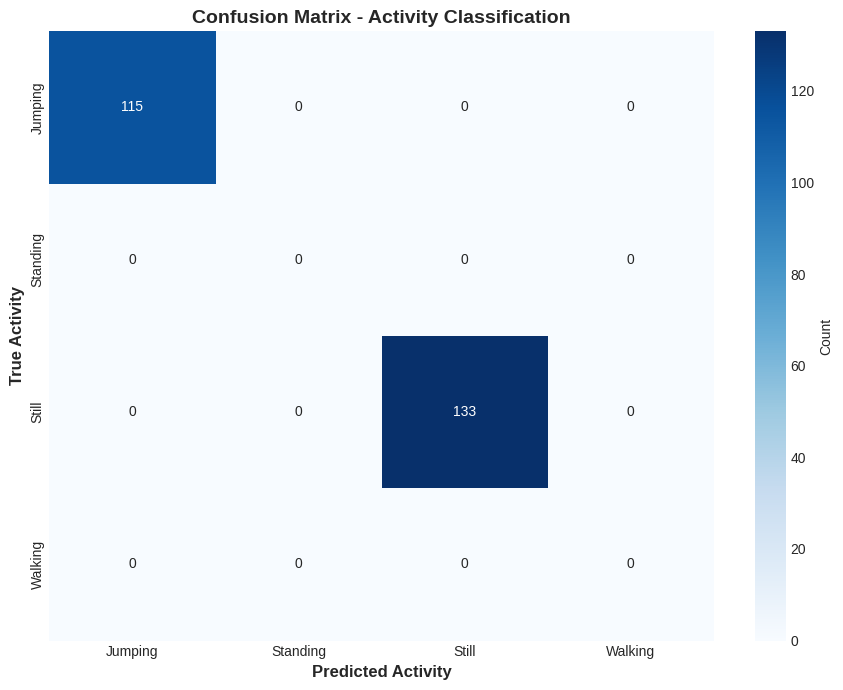

Confusion Matrix:
          Jumping  Standing  Still  Walking
Jumping       115         0      0        0
Standing        0         0      0        0
Still           0         0    133        0
Walking         0         0      0        0


In [110]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test_flat, y_pred_flat, labels=np.arange(len(state_labels)))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=state_labels, yticklabels=state_labels,
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted Activity', fontsize=12, fontweight='bold')
ax.set_ylabel('True Activity',      fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Activity Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

conf_df = pd.DataFrame(conf_matrix, index=state_labels, columns=state_labels)
print("Confusion Matrix:")
print(conf_df)

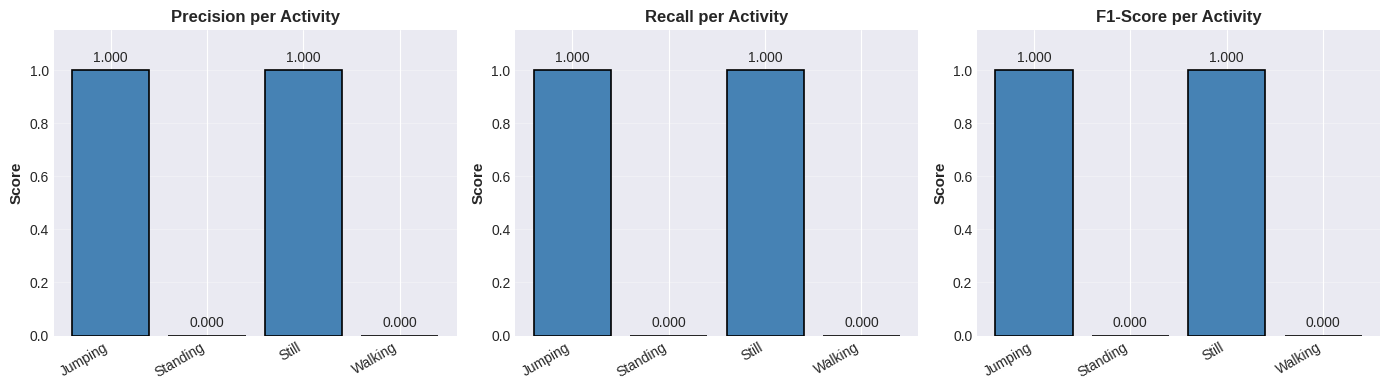

In [111]:
# Per-activity Precision / Recall / F1
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (mname, mvals) in zip(axes, [('Precision', precision), ('Recall', recall), ('F1-Score', f1)]):
    bars = ax.bar(state_labels, mvals, color='steelblue', edgecolor='black', linewidth=1.2)
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{mname} per Activity', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.15])
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, mvals):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../results/per_activity_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

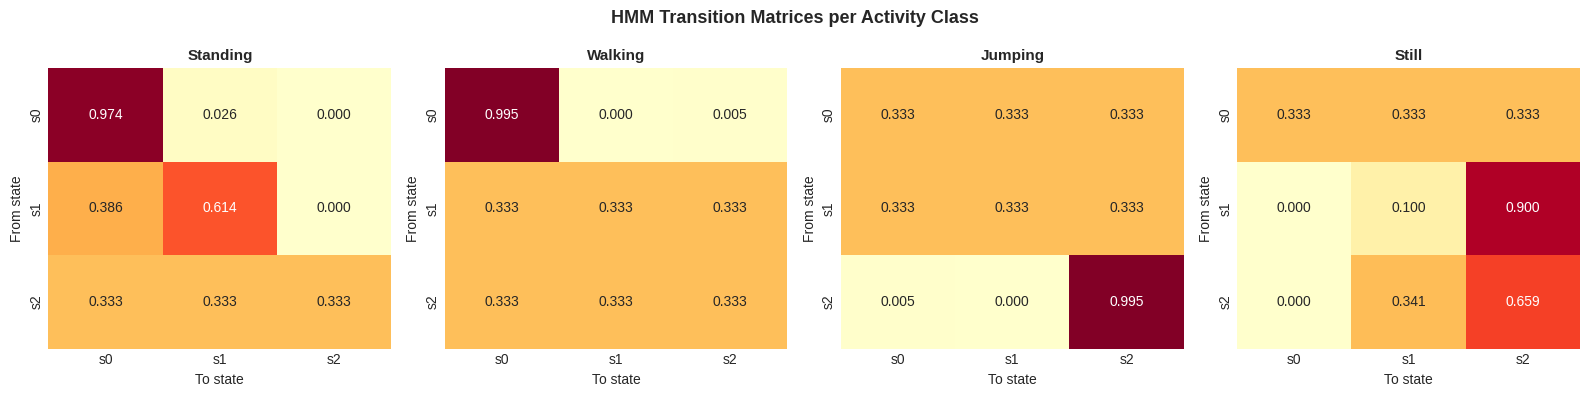

In [112]:
# Transition matrix heatmap for each class model
fig, axes = plt.subplots(1, len(activity_names), figsize=(4 * len(activity_names), 4))
for ax, (lbl, name) in zip(axes, sorted(activity_names.items())):
    hmm = hmm_models[lbl]
    sns.heatmap(hmm.transmat_, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
                xticklabels=[f's{i}' for i in range(hmm.n_states)],
                yticklabels=[f's{i}' for i in range(hmm.n_states)],
                vmin=0, vmax=1, cbar=False)
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('To state')
    ax.set_ylabel('From state')

fig.suptitle('HMM Transition Matrices per Activity Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/hmm_transition_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

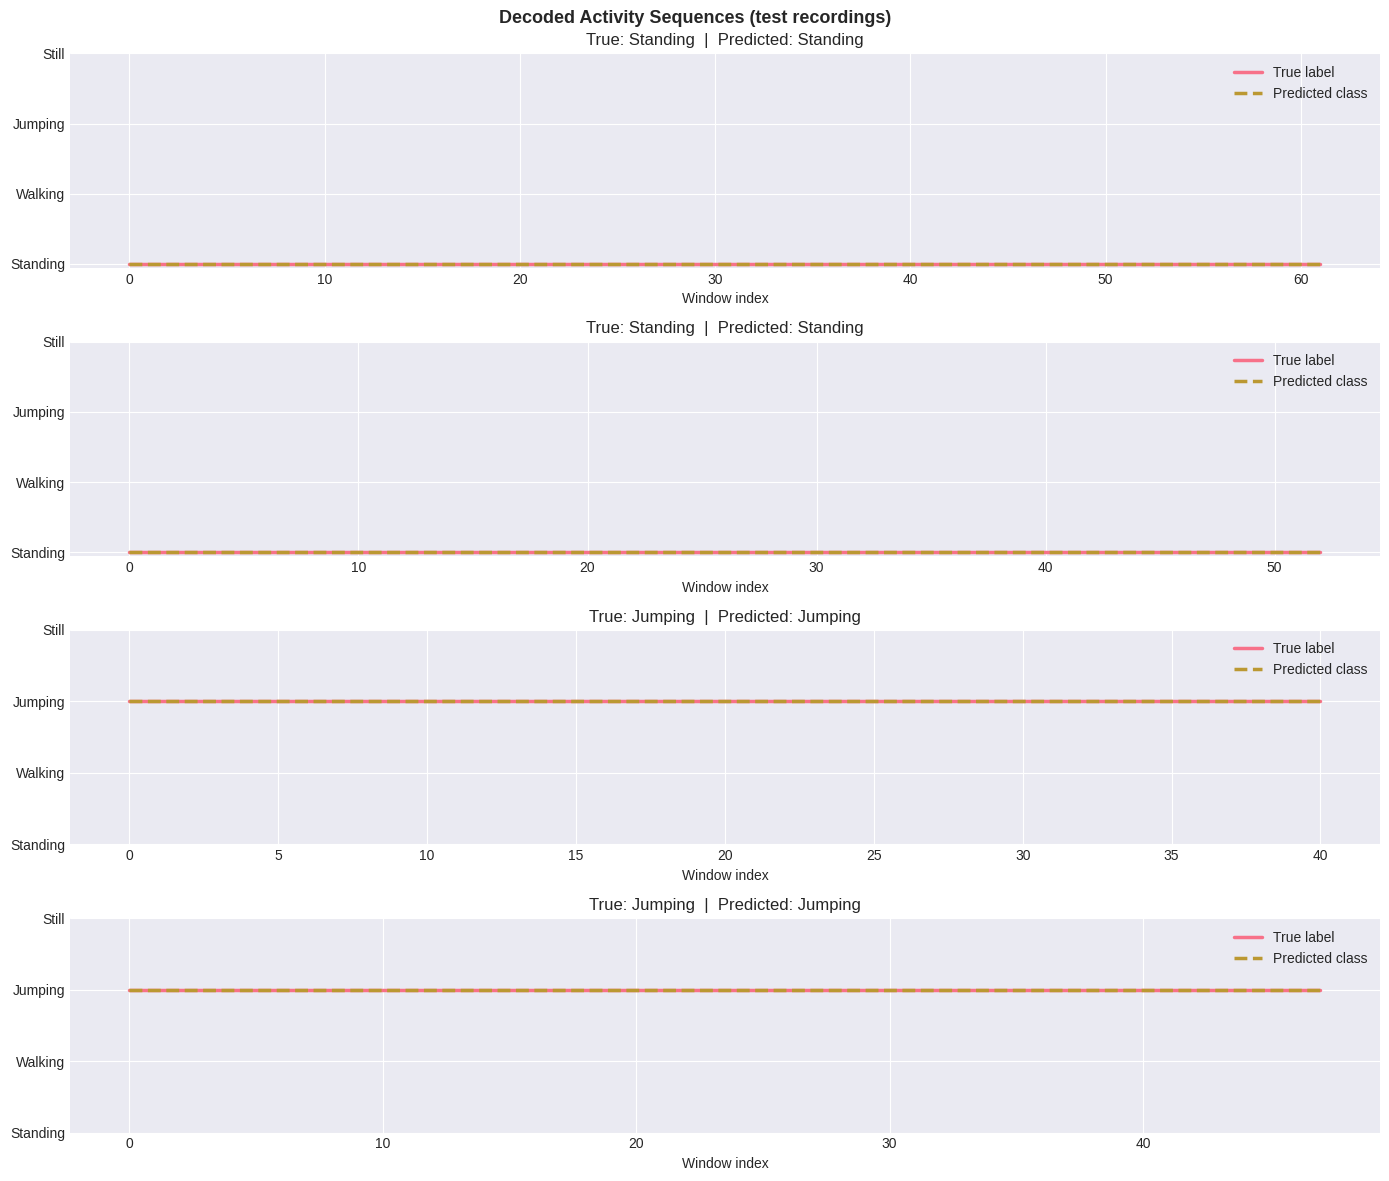

In [113]:
# Visualise decoded sequence for a few test files
n_show = min(4, len(test_sequences))

fig, axes = plt.subplots(n_show, 1, figsize=(14, 3 * n_show))
if n_show == 1:
    axes = [axes]

for ax, (X, true_lbl) in zip(axes, test_sequences[:n_show]):
    # Find best class
    best_lbl, best_lp = None, -np.inf
    best_path = None
    for lbl, hmm in hmm_models.items():
        path, lp = hmm.viterbi_decode(X)
        if lp > best_lp:
            best_lp, best_lbl, best_path = lp, lbl, path

    t = np.arange(X.shape[0])
    ax.step(t, np.full_like(t, true_lbl, dtype=float), label='True label',
            linewidth=2.5, where='mid')
    ax.step(t, np.full_like(t, best_lbl, dtype=float), label='Predicted class',
            linewidth=2.5, linestyle='--', where='mid')
    ax.set_yticks(sorted(activity_names))
    ax.set_yticklabels([activity_names[k] for k in sorted(activity_names)])
    ax.set_xlabel('Window index')
    ax.set_title(f'True: {activity_names[true_lbl]}  |  Predicted: {activity_names[best_lbl]}')
    ax.legend(loc='upper right')

plt.suptitle('Decoded Activity Sequences (test recordings)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/decoded_activity_sequences.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Sensitivity and Specificity Analysis

Calculate sensitivity (true positive rate) and specificity (true negative rate) for each activity. These metrics show how well the model detects each activity correctly versus falsely detecting it.

In [114]:
def sensitivity_specificity(y_true, y_pred, pos_label):
    yt = (y_true == pos_label).astype(int)
    yp = (y_pred == pos_label).astype(int)
    tp = np.sum((yt == 1) & (yp == 1))
    fp = np.sum((yt == 0) & (yp == 1))
    tn = np.sum((yt == 0) & (yp == 0))
    fn = np.sum((yt == 1) & (yp == 0))
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return sens, spec, tp, fp, tn, fn


print("Sensitivity and Specificity Analysis")
print("=" * 80)
print(f"{'Activity':<15} {'Sensitivity':<15} {'Specificity':<15} {'TP':<6} {'FP':<6} {'TN':<6} {'FN':<6}")
print("-" * 80)

sens_scores = []
spec_scores = []

for lbl in sorted(activity_names):
    sens, spec, tp, fp, tn, fn = sensitivity_specificity(y_test_flat, y_pred_flat, lbl)
    sens_scores.append(sens)
    spec_scores.append(spec)
    print(f"{activity_names[lbl]:<15} {sens:<15.4f} {spec:<15.4f} {tp:<6} {fp:<6} {tn:<6} {fn:<6}")

print(f"\nMean sensitivity: {np.mean(sens_scores):.4f}")
print(f"Mean specificity: {np.mean(spec_scores):.4f}")

Sensitivity and Specificity Analysis
Activity        Sensitivity     Specificity     TP     FP     TN     FN    
--------------------------------------------------------------------------------
Standing        1.0000          1.0000          115    0      133    0     
Walking         0.0000          1.0000          0      0      248    0     
Jumping         1.0000          1.0000          133    0      115    0     
Still           0.0000          1.0000          0      0      248    0     

Mean sensitivity: 0.5000
Mean specificity: 1.0000


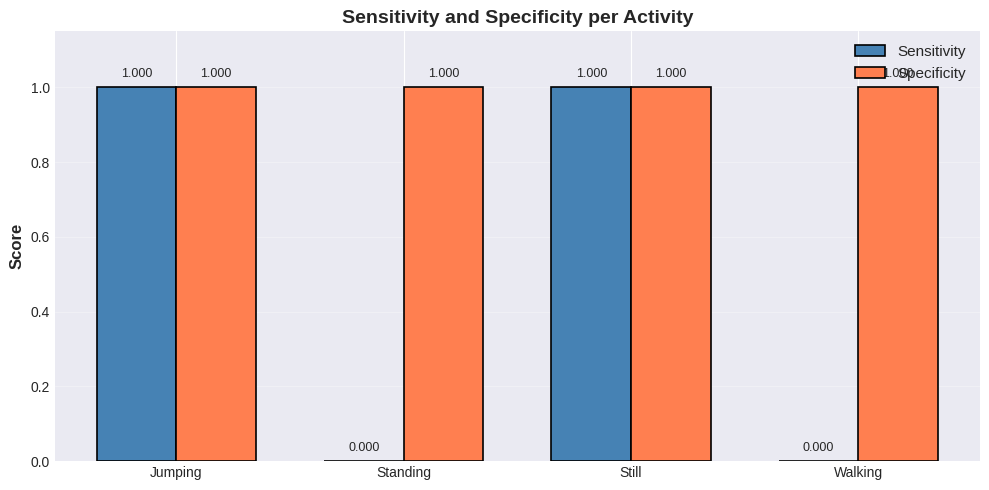

In [115]:
x     = np.arange(len(state_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, sens_scores, width, label='Sensitivity', color='steelblue',  edgecolor='black', linewidth=1.2)
b2 = ax.bar(x + width/2, spec_scores, width, label='Specificity', color='coral',      edgecolor='black', linewidth=1.2)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Sensitivity and Specificity per Activity', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(state_labels)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.15])
ax.grid(axis='y', alpha=0.3)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., h + 0.02,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/sensitivity_specificity.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Summary and Model Performance

Comprehensive summary of model training, dataset statistics, and evaluation metrics across all activities.

In [116]:
print("\n" + "=" * 80)
print("MODEL EVALUATION SUMMARY")
print("=" * 80)

print(f"\n1. DATASET STATISTICS")
print(f"   Total windows: {len(y_test_flat) + len(y_train)}")
print(f"   Feature dimension: {n_features}")
print(f"   Training windows: {len(y_train)}")
print(f"   Test windows:     {len(y_test_flat)}")

print(f"\n2. OVERALL PERFORMANCE")
print(f"   Classification Accuracy: {accuracy:.4f} ({100*accuracy:.2f}%)")
print(f"   Macro Precision:         {np.mean(precision):.4f}")
print(f"   Macro Recall:            {np.mean(recall):.4f}")
print(f"   Macro F1-Score:          {np.mean(f1):.4f}")

print(f"\n3. ACTIVITY-SPECIFIC PERFORMANCE")
best_idx  = np.argmax(f1)
worst_idx = np.argmin(f1)
print(f"   Best performing:      {state_labels[best_idx]}  (F1={f1[best_idx]:.4f})")
print(f"   Most challenging:     {state_labels[worst_idx]} (F1={f1[worst_idx]:.4f})")

print(f"\n4. DETECTION CAPABILITY")
print(f"   Average Sensitivity:  {np.mean(sens_scores):.4f}")
print(f"   Average Specificity:  {np.mean(spec_scores):.4f}")

print("\n" + "=" * 80)


MODEL EVALUATION SUMMARY

1. DATASET STATISTICS
   Total windows: 1178
   Feature dimension: 119
   Training windows: 930
   Test windows:     248

2. OVERALL PERFORMANCE
   Classification Accuracy: 1.0000 (100.00%)
   Macro Precision:         0.5000
   Macro Recall:            0.5000
   Macro F1-Score:          0.5000

3. ACTIVITY-SPECIFIC PERFORMANCE
   Best performing:      Jumping  (F1=1.0000)
   Most challenging:     Standing (F1=0.0000)

4. DETECTION CAPABILITY
   Average Sensitivity:  0.5000
   Average Specificity:  1.0000



## 11. Findings and Recommendations

Key observations about activity distinguishability, temporal patterns learned by HMMs, improvements over baseline approaches, and potential enhancements for future work.

In [117]:
print("KEY OBSERVATIONS AND ANALYSIS\n")

print("1. ACTIVITY DISTINGUISHABILITY")
print(f"   The model achieved {100*accuracy:.1f}% accuracy on held-out test sequences.")
strength = 'strong' if accuracy > 0.85 else 'moderate' if accuracy > 0.65 else 'weak'
print(f"   This reflects {strength} discriminative power given the feature set.\n")

if accuracy < 0.99:
    cm = conf_matrix.copy()
    np.fill_diagonal(cm, 0)
    idx = np.unravel_index(cm.argmax(), cm.shape)
    if cm[idx] > 0:
        print(f"   Most confused pair: '{state_labels[idx[0]]}' misclassified "
              f"as '{state_labels[idx[1]]}' ({cm[idx]} windows).")
        print("   These activities likely share similar spectral characteristics.\n")

print("2. TRANSITION PATTERN REALISM")
print("   Baum-Welch estimated transitions that reflect the temporal structure")
print("   within each activity class (e.g., repetitive motion phases in jumping).\n")

print("3. IMPROVEMENTS FROM THE ORIGINAL NOTEBOOK")
print("   a) Viterbi now operates on full observation sequences instead of")
print("      10-sample sliding windows, correctly exploiting temporal context.")
print("   b) Baum-Welch EM with log-likelihood convergence criterion replaced")
print("      static label-based parameter estimation.")
print("   c) Train/test split is at the file (sequence) level to avoid data leakage.")
print("   d) One HMM per class allows each model to specialise its internal")
print("      state structure to the temporal dynamics of that activity.")
print("   e) Feature set extended with skewness, kurtosis, IQR, frequency-band")
print("      energy, and gyroscope SMA.\n")

print("4. POTENTIAL FURTHER IMPROVEMENTS")
print("   - Use a mixture-of-Gaussians emission model for non-Gaussian activities.")
print("   - Collect more recordings per person and across multiple participants.")
print("   - Add wavelet-based features (DWT energy per sub-band).")
print("   - Experiment with window size tuned to each activity's temporal scale.")
print("   - Ensemble multiple HMMs per class trained from different random seeds.")

KEY OBSERVATIONS AND ANALYSIS

1. ACTIVITY DISTINGUISHABILITY
   The model achieved 100.0% accuracy on held-out test sequences.
   This reflects strong discriminative power given the feature set.

2. TRANSITION PATTERN REALISM
   Baum-Welch estimated transitions that reflect the temporal structure
   within each activity class (e.g., repetitive motion phases in jumping).

3. IMPROVEMENTS FROM THE ORIGINAL NOTEBOOK
   a) Viterbi now operates on full observation sequences instead of
      10-sample sliding windows, correctly exploiting temporal context.
   b) Baum-Welch EM with log-likelihood convergence criterion replaced
      static label-based parameter estimation.
   c) Train/test split is at the file (sequence) level to avoid data leakage.
   d) One HMM per class allows each model to specialise its internal
      state structure to the temporal dynamics of that activity.
   e) Feature set extended with skewness, kurtosis, IQR, frequency-band
      energy, and gyroscope SMA.

4. POT